In [1]:
import numpy as np 
import pandas as pd
import os, sys, glob, tables, subprocess
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
pd.set_option('display.max_columns', None)

from traitlets.config import Config
from ctapipe.visualization import CameraDisplay
from ctapipe.io import EventSeeker, EventSource
from ctapipe.instrument import CameraGeometry
import astropy.units as u

from ctapipe.image import tailcuts_clean

from ctapipe.io import read_table
from lstchain.io.io import dl1_images_lstcam_key, dl1_params_lstcam_key, dl2_params_lstcam_key

from ctapipe.instrument import SubarrayDescription
subarray_info = SubarrayDescription.from_hdf("data/dl1_LST-1.Run19799.0000.h5")
camgeom = subarray_info.tel[1].camera.geometry

In [2]:
fs = []
for factor in fs[:]:
    print(factor)
    file_input  = f"dl1_LST-1.Run19799.0000.h5"
    file_output = f"dl1_LST-1.Run19799.0000_{factor:.3f}.h5"

    command  = f"lstchain_dl1ab --input-file {file_input} --output-file {file_output} "
    command += f"--light-scaling {factor}"

    subprocess.run(command, shell=True, text=True)

## Analysis

In [3]:
file_original = "data/dl1_LST-1.Run19799.0000.h5"
files_scaled = np.sort(glob.glob("data/dl1_LST-1.Run19799.0000_???.h5"))

image_table_original = read_table(file_original, dl1_images_lstcam_key)
image_table_original["n_pixels"] = [mask.sum() for mask in image_table_original["image_mask"]]

image_tables, parameters, scales, flag_1 = [], [], [], True
for i, f in enumerate(files_scaled):
    print(f)
    
    s = float(f.split("0000_")[1].split(".h5")[0])

    image_tables.append(read_table(f, dl1_images_lstcam_key))
    parameters.append(read_table(f, dl1_params_lstcam_key))
    scales.append(s)

print("\nComputing n_pixels")
for param, im_tab in zip(parameters, image_tables):
    im_tab["n_pixels"] = [mask.sum() for mask in im_tab["image_mask"]]
print("\nComputing n_pixels_diff")
for param, im_tab in zip(parameters, image_tables):    
    param["n_pixels_diff"] = im_tab["n_pixels"] - image_table_original["n_pixels"]

data/dl1_LST-1.Run19799.0000_0.9.h5
data/dl1_LST-1.Run19799.0000_1.0.h5
data/dl1_LST-1.Run19799.0000_1.2.h5
data/dl1_LST-1.Run19799.0000_1.5.h5
data/dl1_LST-1.Run19799.0000_1.8.h5
data/dl1_LST-1.Run19799.0000_2.0.h5

Computing n_pixels

Computing n_pixels_diff


In [4]:
f0 = "/fefs/aswg/data/real/DL2/20241125/v0.10/tailcut84/nsb_tuning_0.22/dl2_LST-1.Run19799.h5"
f1 = "/fefs/aswg/workspace/juan.jimenez/data/real/mono/S241125n/v0.10.18/GammaDiffuse/prod_light_scaling/DL2/dl2_LST-1.Run19799.h5"
dl2_tab0 = read_table(f0, dl2_params_lstcam_key).to_pandas()
dl2_tab1 = read_table(f1, dl2_params_lstcam_key).to_pandas()

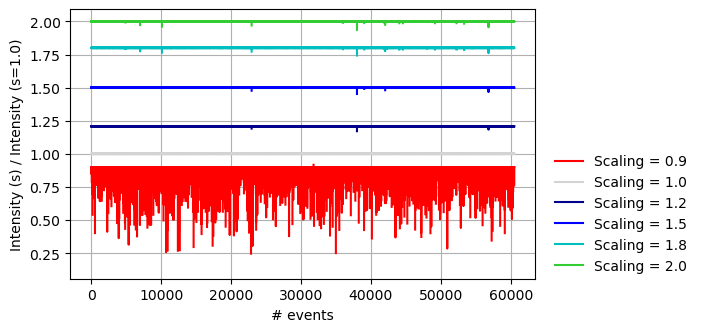

In [5]:
fig, ax = plt.subplots(figsize=(6, 3.5))

for (i, s), c in zip(enumerate(scales), ["r", "lightgray", "darkblue", "b", "c", "limegreen"]):
    ax.plot(parameters[i]["intensity"]/parameters[1]["intensity"], "-", c=c, label=f"Scaling = {s}")

ax.legend(loc=(1.03, 0), frameon=False)
ax.set_xlabel("# events"); ax.set_ylabel("Intensity (s) / Intensity (s=1.0)"); ax.grid()

plt.show()

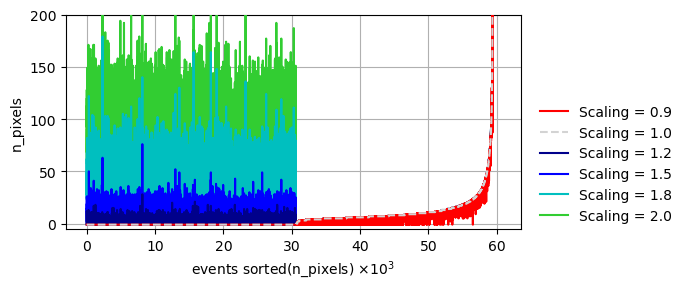

In [6]:
fig, (ax1) = plt.subplots(1, 1, figsize=(7, 3), sharex=True)

sorting = np.argsort(parameters[1]["n_pixels"])

x = np.arange(len(parameters[0]["n_pixels"])) / 1000
for (i, s), c in zip(enumerate(scales), ["r", "lightgray", "darkblue", "b", "c", "limegreen"]):
    y = parameters[i]["n_pixels"]
    ax1.plot(x, y[sorting], color=c, label=f"Scaling = {s}", lw=1.5, 
            ls="-" if s != 1.0 else "--", zorder=10-i if s != 1.0 else 10)

ax1.set_xlabel("events sorted(n_pixels) $\\times 10^3$")
ax1.legend(loc=(1.03, 0), frameon=False)
ax1.set_ylim(-5, 200); ax1.grid()
ax1.set_ylabel("n_pixels")
fig.tight_layout()

plt.savefig(f"plots/plot_n_pixels_sorted.png", bbox_inches="tight", dpi=300)
plt.show()

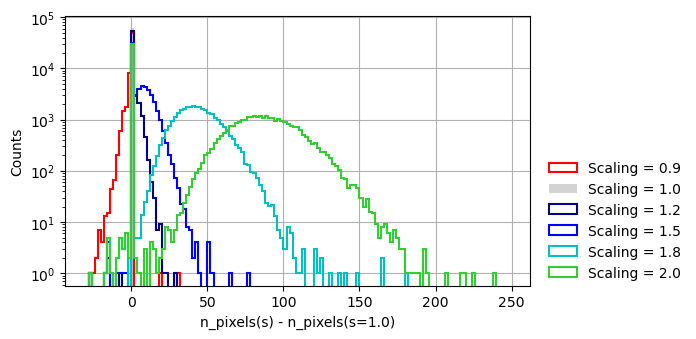

In [7]:
fig, ax = plt.subplots(figsize=(6, 3.5))

for (i, s), c in zip(enumerate(scales), ["r", "lightgray", "darkblue", "b", "c", "limegreen"]):
    ht = "step" if i != 1 else "stepfilled"
    ax.hist(parameters[i]["n_pixels"] - parameters[1]["n_pixels"], 
            bins=np.arange(-30, 250, 2), histtype=ht, color=c,
            label=f"Scaling = {s}", lw=1.5)

ax.set_xlabel("n_pixels(s) - n_pixels(s=1.0)"); ax.set_ylabel("Counts")
ax.legend(loc=(1.03, 0), frameon=False)
ax.set_yscale("log"); ax.grid()

plt.show()

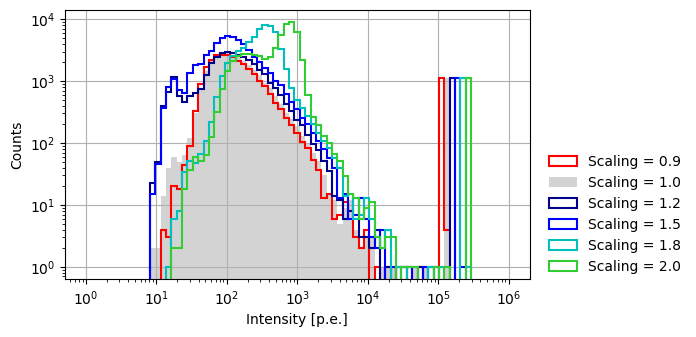

In [8]:
fig, ax = plt.subplots(figsize=(6, 3.5))

for (i, s), c in zip(enumerate(scales), ["r", "lightgray", "darkblue", "b", "c", "limegreen"]):
    ht = "step" if i != 1 else "stepfilled"
    ax.hist(parameters[i]["intensity"], bins=np.logspace(0, 6, 80), histtype=ht, color=c,
            label=f"Scaling = {s}", lw=1.5)

ax.set_xlabel("Intensity [p.e.]"); ax.set_ylabel("Counts")
ax.legend(loc=(1.03, 0), frameon=False)
ax.loglog(); ax.grid()

plt.show()

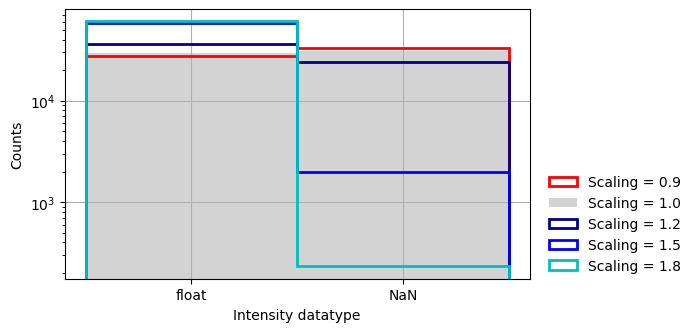

In [9]:
fig, ax = plt.subplots(figsize=(6, 3.5))

for (i, s), c in zip(enumerate(scales), ["r", "lightgray", "darkblue", "b", "c", "limegreen"]):
    if s < 1.9:
        ht = "step" if i != 1 else "stepfilled"
        ax.hist(np.isnan(parameters[i]["intensity"]).astype(float), bins=[-0.5, 0.5, 1.5], 
                 alpha=1, histtype=ht, color=c, label=f"Scaling = {s}", ls="-", lw=2)

ax.set_xticks([0, 1])
ax.set_xticklabels(["float", "NaN"])
ax.set_xlabel("Intensity datatype"); ax.set_ylabel("Counts")
ax.set_yscale("log"); ax.grid()
ax.legend(loc=(1.03, 0), frameon=False)

plt.show()

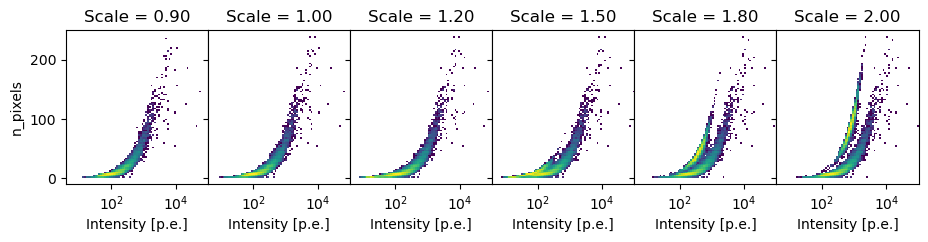

In [10]:
fig, axes = plt.subplots(1, 6, figsize=(11, 2), sharey=True)

for (i, s), c in zip(enumerate(scales), ["r", "lightgray", "darkblue", "b", "c", "limegreen"]):
    ax = axes[i]
    ax.hist2d(parameters[i]["intensity"], parameters[i]["n_pixels"], 
              bins=(np.logspace(0.6, 5, 80), np.linspace(-10, 250, 100)), norm=LogNorm())
    ax.set_title(f"Scale = {s:.2f}")
    
for ax in axes:
    ax.set_xscale("log")
    ax.set_xlabel("Intensity [p.e.]")
    ax.set_facecolor("1")
axes[0].set_ylabel("n_pixels")
plt.subplots_adjust(wspace=0, hspace=0)
plt.show()

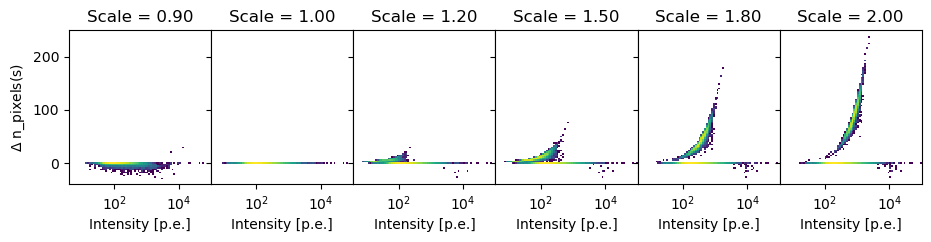

In [11]:
fig, axes = plt.subplots(1, 6, figsize=(11, 2), sharey=True)

for (i, s), c in zip(enumerate(scales), ["r", "lightgray", "darkblue", "b", "c", "limegreen"]):
    ax = axes[i]
    ax.hist2d(parameters[i]["intensity"], parameters[i]["n_pixels_diff"], 
              bins=(np.logspace(0.6, 5, 80), np.linspace(-40, 250, 100)), norm=LogNorm())
    ax.set_title(f"Scale = {s:.2f}")
    
for ax in axes:
    ax.set_xscale("log")
    ax.set_xlabel("Intensity [p.e.]")
    ax.set_facecolor("1")
axes[0].set_ylabel("$\Delta$ n_pixels(s)")
plt.subplots_adjust(wspace=0, hspace=0)
plt.show()

# Querying to find event numbers

In [12]:
df0 = parameters[1].to_pandas()
df1 = parameters[2].to_pandas()

tmp1 = df1.query("intensity > 1e2 and n_pixels_diff > 0 and event_type == 32").sort_values(by="intensity", ascending=False)
event_numbers, intensities0, intensities1    = [], [], []
n_pixels0, n_pixels1, gammaness0, gammaness1 = [], [], [], []
image0, image1, mask0, mask1, peak0, peak1 = [], [], [], [], [], []
nevents, nmaxevents = 0, 20
for i in range(len(tmp1)):
    if nevents > nmaxevents:
        break
#     try:
    tmp0 = df0.query(f"event_id == {event_id}")
    
    event_id = tmp1.iloc[i]['event_id']
    i0, i1 = tmp0.iloc[0]['intensity'], tmp1.iloc[i]['intensity']
    n0, n1 = tmp0.iloc[0]['n_pixels'], tmp1.iloc[i]['n_pixels']

    tmpdl20 = dl2_tab0.query(f"event_id == {event_id}")
    tmpdl21 = dl2_tab1.query(f"event_id == {event_id}")
    g0 = tmpdl20.iloc[0]['gammaness'] if len(tmpdl20) > 0 else np.nan
    g1 = tmpdl21.iloc[0]['gammaness']

    
    print(f"\nevent_id = {event_id}\n")
    print(f"   -   n_pixels,   {n0:.0f},     \t {n1:.0f}")
    print(f"   -   intensity,  {i0:.0f} p.e.,\t {i1:.0f} p.e.")
    print(f"   -   gammaness,  {g0:.3f},     \t {g1:.3f}")

    imt0 = image_table_original[image_table_original["event_id"] == event_id][0]
    imt1 = image_tables[2][image_tables[2]["event_id"] == event_id][0]

    event_numbers.append(event_id)
    intensities0.append(i0); intensities1.append(i1)
    n_pixels0.append(n0); n_pixels1.append(n1)
    gammaness0.append(g0); gammaness1.append(g1)
    image0.append(imt0["image"]); image1.append(imt1["image"])
    mask0.append(imt0["image_mask"]); mask1.append(imt1["image_mask"])
    peak0.append(imt0["peak_time"]); peak1.append(imt1["peak_time"])
    nevents += 1
#     except:
#         pass

NameError: name 'event_id' is not defined

In [ ]:
for i in range(len(event_numbers[:])):
    ev = event_numbers[i]
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(10, 8.5), sharex=True)
    fig.suptitle(f"event_id = {ev}")
    
    disp1 = CameraDisplay(camgeom, ax=ax1, show_frame=False, title=f"Scaling = 1.00")
    disp2 = CameraDisplay(camgeom, ax=ax2, show_frame=False, title=f"Scaling = 1.21")
    t  = f"n_pixels = {n_pixels0[i]}, Int = {intensities0[i]:.0f}\n$\gamma$ = {gammaness0[i]:.2f}"
    disp3 = CameraDisplay(camgeom, ax=ax3, show_frame=False, title=t, cmap="viridis")
    t  = f"n_pixels = {n_pixels1[i]}, Int = {intensities1[i]:.0f}\n$\gamma$ = {gammaness1[i]:.2f}"
    disp4 = CameraDisplay(camgeom, ax=ax4, show_frame=False, title=t, cmap="viridis")

    disp1.image, disp2.image = image0[i], image1[i]
    disp3.image, disp4.image = peak0[i], peak1[i]
    disp1.add_colorbar(label="Charge", ax=ax1); disp2.add_colorbar(label="Charge", ax=ax2)
    disp3.add_colorbar(label="Peak [ns]", ax=ax3); disp4.add_colorbar(label="Peak[ns]", ax=ax4)

    disp3.highlight_pixels(mask0[i], alpha=1, linewidth=1.2, color="r")
    disp4.highlight_pixels(mask1[i], alpha=1, linewidth=1.2, color="r")

    maxim = np.max([np.max(image0[i]), np.max(image1[i])])
    disp1.set_limits_minmax(0, maxim); disp2.set_limits_minmax(0, maxim)
    disp3.set_limits_minmax(0, 40); disp4.set_limits_minmax(0, 40)
    ax2.set_ylabel(""); ax4.set_ylabel("")
    ax1.set_xlabel(""); ax2.set_xlabel("")
    fig.tight_layout()
    
    plt.savefig(f"plots/tmp_events/plot_{ev}.png", bbox_inches="tight", dpi=300)
    plt.show()

## Evolution of distribution

In [ ]:
file_original = "data/dl1_LST-1.Run19799.0000.h5"
files_scaled = np.sort(glob.glob("data/dl1_LST-1.Run19799.0000_?????.h5"))

image_table_original = read_table(file_original, dl1_images_lstcam_key)
image_table_original["n_pixels"] = [mask.sum() for mask in image_table_original["image_mask"]]

image_tables, parameters, scales, flag_1 = [], [], [], True
for i, f in enumerate(files_scaled):
    print(f)
    
    s = float(f.split("0000_")[1].split(".h5")[0])
    
    if s > 1.0 and flag_1:
        image_tables.append(read_table(file_original, dl1_images_lstcam_key))
        parameters.append(read_table(file_original, dl1_params_lstcam_key))
        scales.append(1.0); flag_1 = False

    image_tables.append(read_table(f, dl1_images_lstcam_key))
    parameters.append(read_table(f, dl1_params_lstcam_key))
    scales.append(s)

print("\nComputing n_pixels")
for param, im_tab in zip(parameters, image_tables):
    im_tab["n_pixels"] = [mask.sum() for mask in im_tab["image_mask"]]
print("\nComputing n_pixels_diff")
for param, im_tab in zip(parameters, image_tables):    
    param["n_pixels_diff"] = im_tab["n_pixels"] - image_table_original["n_pixels"]

In [ ]:
ints_value, ints_nan = [], []
for p in parameters:
    ints = p["intensity"]
    l = len(ints)
    ints_value.append(np.sum(~np.isnan(ints)) / l)
    ints_nan.append(np.sum(np.isnan(ints)) / l)
ints_value, ints_nan = np.array(ints_value), np.array(ints_nan) 

In [ ]:
fig, ax = plt.subplots(figsize=(6, 3))

ax.plot(scales, ints_value * 100, color="k")
ax.fill_between(scales, ints_value * 100, color="darkblue", alpha=0.4, ls="", 
                label="Events surviving\ncleaning")
ax.fill_between(scales, 100, ints_value * 100, color="deeppink", alpha=0.4, ls="", 
                label="Events not surviving\ncleaning")
# ax.plot(scales, ints_nan * 100, color="dodgerblue", label="Events not surviving\ncleaning")

ax.axvline(1, color="k", ls="--")
ax.axvline(1.21, color="k", ls=":", label="\"Proper\" scaling")

ax.set_xlabel("Scaling Factor"); ax.set_ylabel("Events [%]")
ax.grid(); ax.legend(frameon=True, loc=7); ax.set_xlim(0.7, 2); ax.set_ylim(0, 100)

plt.savefig(f"plots/plot_percent_surviving.png", bbox_inches="tight", dpi=300)
plt.show()

In [ ]:
for (i, p), s in zip(enumerate(parameters[::]), scales):
    fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.2), sharey=True)
    
    ax.hist2d(p["intensity"], p["n_pixels_diff"], 
              bins=(np.logspace(0.6, 5, 80), np.linspace(-50, 250, 100)), norm=LogNorm())
    
    ax.set_title(f"Scale = {s:.3f}")
    
    ax.set_xscale("log")
    ax.set_xlabel("Intensity [p.e.]")
    ax.set_ylabel("$\Delta$ n_pixels")
    plt.subplots_adjust(wspace=0, hspace=0)

    plt.savefig(f"plots/tmp/plot_{s:.3f}.png", bbox_inches="tight", dpi=300)
    plt.show()

In [ ]:
import os, imageio
from PIL import Image
import matplotlib.pyplot as plt

def create_gif_from_folder(folder_path, output_gif_path, duration=0.5, fps=100):
    """
    Create a GIF from images in a folder and set it to loop infinitely.

     - param folder_path: Path to the folder containing images.
     - param output_gif_path: Path to save the output GIF.
     - param duration: Duration (in seconds) to display each frame.
    """
    # Get all files from the folder
    files = sorted([os.path.join(folder_path, f) for f in os.listdir(folder_path) if f.endswith(('.png', '.JPG', '.jpeg', '.bmp', '.gif'))])
    
    # Read images
    images = [Image.open(file) for file in files]
    
    # Save as GIF with infinite looping
    imageio.mimsave(
        output_gif_path,
        images,
        duration=duration * 1000,  # Convert seconds to milliseconds
        loop=0,  # Set loop to 0 for infinite looping
        fps = 100
    )
    
    print(f"GIF saved to {output_gif_path}")

# Example usage
folder_path = "./plots/tmp/"
output_gif_path = "plots/output.gif"
create_gif_from_folder(folder_path, output_gif_path, duration=0.1, fps=30)